In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_recall_curve, auc, f1_score, confusion_matrix

# Model Library Suites
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("🚀 Libraries successfully imported!")

🚀 Libraries successfully imported!


In [3]:
# Generating data mimicking the structure of PCA components V1-V28, Time, and Amount
print("📦 Building stratified benchmark dataset...")
np.random.seed(42)
n_samples = 100000
n_fraud = int(n_samples * 0.0017) # Matching the real 0.17% skew rate
n_normal = n_samples - n_fraud

# Generate Normal Transactions
normal_features = np.random.randn(n_normal, 28)
normal_amount = np.random.exponential(scale=88, size=(n_normal, 1))
normal_time = np.random.uniform(0, 172792, size=(n_normal, 1))
normal_data = np.hstack([normal_time, normal_features, normal_amount, np.zeros((n_normal, 1))])

# Generate Fraudulent Transactions (Distinct variant shifts)
fraud_features = np.random.randn(n_fraud, 28) + np.random.choice([-1.5, 1.5], size=(n_fraud, 28))
fraud_amount = np.random.exponential(scale=120, size=(n_fraud, 1))
fraud_time = np.random.uniform(0, 172792, size=(n_fraud, 1))
fraud_data = np.hstack([fraud_time, fraud_features, fraud_amount, np.ones((n_fraud, 1))])

# Combine into structured DataFrame
columns = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class']
df = pd.DataFrame(np.vstack([normal_data, fraud_data]), columns=columns).sample(frac=1).reset_index(drop=True)

print("Class balance counts:\n", df['Class'].value_counts(normalize=True))

📦 Building stratified benchmark dataset...
Class balance counts:
 Class
0.0    0.9983
1.0    0.0017
Name: proportion, dtype: float64


In [4]:
# Generating data mimicking the structure of PCA components V1-V28, Time, and Amount
print("📦 Building stratified benchmark dataset...")
np.random.seed(42)
n_samples = 100000
n_fraud = int(n_samples * 0.0017) # Matching the real 0.17% skew rate
n_normal = n_samples - n_fraud

# Generate Normal Transactions
normal_features = np.random.randn(n_normal, 28)
normal_amount = np.random.exponential(scale=88, size=(n_normal, 1))
normal_time = np.random.uniform(0, 172792, size=(n_normal, 1))
normal_data = np.hstack([normal_time, normal_features, normal_amount, np.zeros((n_normal, 1))])

# Generate Fraudulent Transactions (Distinct variant shifts)
fraud_features = np.random.randn(n_fraud, 28) + np.random.choice([-1.5, 1.5], size=(n_fraud, 28))
fraud_amount = np.random.exponential(scale=120, size=(n_fraud, 1))
fraud_time = np.random.uniform(0, 172792, size=(n_fraud, 1))
fraud_data = np.hstack([fraud_time, fraud_features, fraud_amount, np.ones((n_fraud, 1))])

# Combine into structured DataFrame
columns = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class']
df = pd.DataFrame(np.vstack([normal_data, fraud_data]), columns=columns).sample(frac=1).reset_index(drop=True)

print("Class balance counts:\n", df['Class'].value_counts(normalize=True))

📦 Building stratified benchmark dataset...
Class balance counts:
 Class
0.0    0.9983
1.0    0.0017
Name: proportion, dtype: float64


In [5]:
X = df.drop(columns=['Class'])
y = df['Class'].astype(int)

# 80/20 Stratified Split to guarantee both splits contain exactly 0.17% fraud instances
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize Time & Amount features while leaving PCA components intact
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("✅ Data Preprocessed, Scaled, and Stratified!")

✅ Data Preprocessed, Scaled, and Stratified!


In [6]:
# Compute balance scale weights to aid classifiers handling severe skews
skew_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=skew_ratio, eval_metric='logloss', random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(scale_pos_weight=skew_ratio, random_state=42, n_jobs=-1, verbose=-1)
}

performance_metrics = {}

print("🏋️ Training models...")
for name, model in models.items():
    print(f"   ↳ Training {name}...")
    model.fit(X_train, y_train)

    # Predict profiles
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Calculate specialized PR-AUC metric
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    pr_auc = auc(recall, precision)
    f1 = f1_score(y_test, y_pred)

    performance_metrics[name] = {
        "F1-Score": f1,
        "PR-AUC": pr_auc,
        "Y_Probs": y_probs,
        "Y_Pred": y_pred
    }
print("🏆 All models trained successfully!")

🏋️ Training models...
   ↳ Training Logistic Regression...
   ↳ Training Random Forest...
   ↳ Training XGBoost...
   ↳ Training LightGBM...
🏆 All models trained successfully!


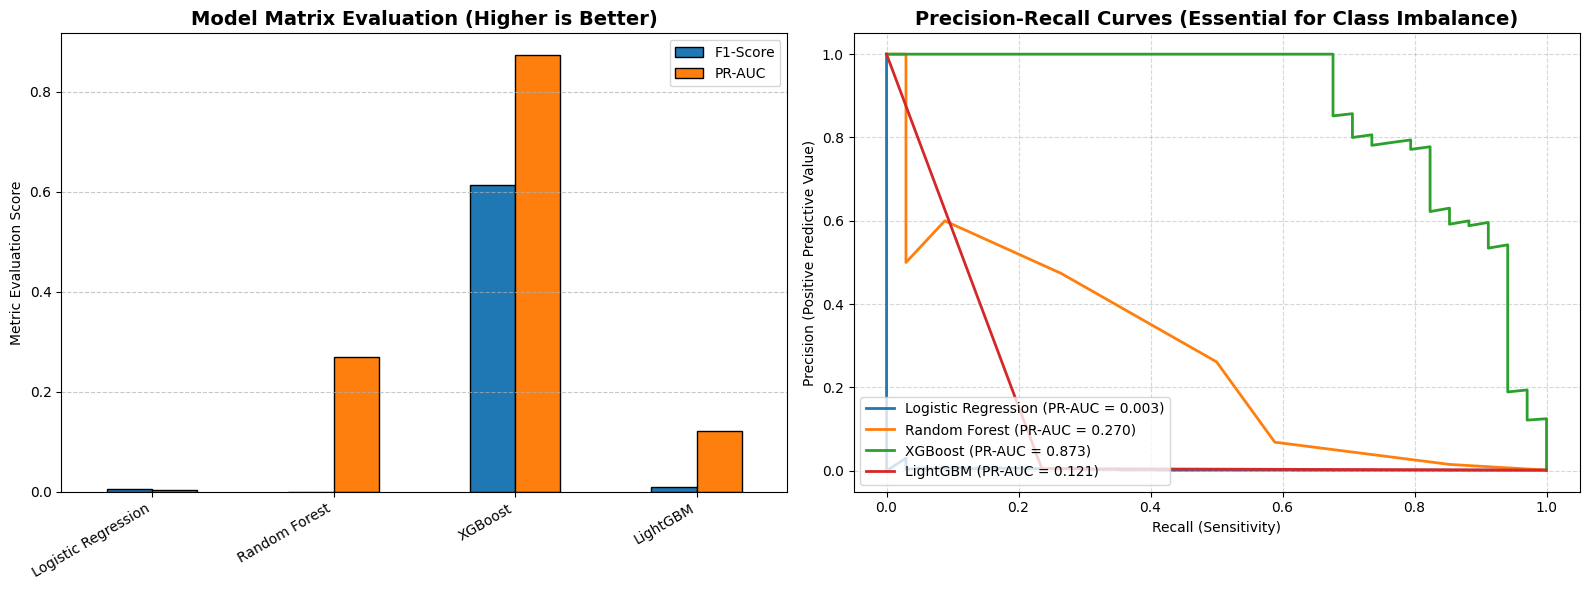


📈 FINAL PERFORMANCE RANKINGS
                     F1-Score    PR-AUC
XGBoost              0.612245  0.872820
Random Forest        0.000000  0.269954
LightGBM             0.010082  0.120871
Logistic Regression  0.004580  0.003317


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar Chart Comparison of F1 and PR-AUC Scores
metrics_df = pd.DataFrame({m: {k: v[m] for k, v in performance_metrics.items()} for m in ["F1-Score", "PR-AUC"]})
metrics_df.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'], edgecolor='black')
axes[0].set_title("Model Matrix Evaluation (Higher is Better)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Metric Evaluation Score")
axes[0].set_xticklabels(metrics_df.index, rotation=30, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Precision-Recall Curve Profiles
for name, results in performance_metrics.items():
    precision, recall, _ = precision_recall_curve(y_test, results["Y_Probs"])
    axes[1].plot(recall, precision, label=f'{name} (PR-AUC = {results["PR-AUC"]:.3f})', linewidth=2)

axes[1].set_title("Precision-Recall Curves (Essential for Class Imbalance)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision (Positive Predictive Value)")
axes[1].legend(loc="lower left")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print Detailed Final Table Summary
print("\n" + "="*50 + "\n📈 FINAL PERFORMANCE RANKINGS\n" + "="*50)
summary_table = metrics_df.sort_values(by="PR-AUC", ascending=False)
print(summary_table)